![Houston, USA](https://images.pexels.com/photos/18441168/pexels-photo-18441168.jpeg)
<sup>Houston, USA - Erik Mclean, pexels.com</sup>

# Uber with SQL

Analysis of database using SQL and Python.

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = "data/rideshare.db"  # update path if needed
conn = sqlite3.connect(DB_PATH)

def q(sql):
    return pd.read_sql(sql, conn)


## Database overview

In [ ]:
tables = q("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")['name'].tolist()

row_counts = []
for table in tables:
    row_counts.append({
        "table": table,
        "rows": q(f"SELECT COUNT(*) AS n FROM {table}")["n"][0]
    })

pd.DataFrame(row_counts)


,table,rows
0,cancellations,2966
1,drivers,400
2,locations,40
3,payments,16827
4,reviews,15136
5,riders,1600
6,trips,20000
7,users,2000


In [9]:
q("""SELECT *
FROM cancellations
LIMIT 3;""")

,cancel_id,trip_id,cancelled_by,reason,cancelled_at
0,1,2,driver,personal emergency,2024-01-25 20:55:28
1,2,7,driver,wrong pickup,2023-06-02 19:32:48
2,3,16,driver,rider rating too low,2022-05-13 15:56:17


In [10]:
q("""SELECT *
FROM drivers
LIMIT 3;""")

,driver_id,user_id,vehicle_make,vehicle_model,vehicle_year,license_plate,rating,join_date,is_active
0,1,1781,Kia,Soul,2015,ZVJ-2140,4.10,2019-12-22,1
1,2,408,Hyundai,Tucson,2016,WLW-3906,4.21,2020-12-14,1
2,3,693,Hyundai,Sonata,2014,WEA-5140,3.81,2023-07-25,1


In [32]:
q("""SELECT *
FROM locations
LIMIT 3;""")

,location_id,zone_name,city,latitude,longitude,zone_type
0,1,Times Square,New York,40.7580,-73.9855,commercial
1,2,JFK Airport,New York,40.6413,-73.7781,airport
2,3,LaGuardia Airport,New York,40.7769,-73.8740,airport


In [12]:
q("""SELECT *
FROM payments
LIMIT 3;""")

,payment_id,trip_id,amount,method,status,paid_at
0,1,1,68.55,wallet,success,2024-06-24 14:24:15
1,2,3,6.36,wallet,success,2023-08-17 09:36:16
2,3,4,21.98,cash,success,2022-11-21 10:17:36


In [13]:
q("""SELECT *
FROM reviews
LIMIT 3;""")

,review_id,trip_id,reviewer_id,reviewee_id,rating,comment,reviewed_at
0,1,1,1958,1001,4,Very comfortable ride.,2024-06-24 14:52:11
1,2,1,1001,1958,4,Super friendly and helpful.,2024-06-24 16:09:11
2,3,3,324,373,4,Very clean car.,2023-08-17 11:08:06


In [14]:
q("""SELECT *
FROM riders
LIMIT 3;""")

,rider_id,user_id,rating,total_trips,created_at
0,1,1958,4.66,1,2020-09-13 01:52:12
1,2,373,3.76,2,2019-11-03 13:23:24
2,3,680,3.03,8,2020-01-23 08:54:39


In [16]:
q("""SELECT *
FROM trips
LIMIT 3;""")

,trip_id,rider_id,driver_id,pickup_location_id,dropoff_location_id,requested_at,started_at,completed_at,status,distance_km,duration_mins,base_fare,surge_multiplier,total_fare,payment_method
0,1,1,34,26,29,2024-06-24 12:20:11,2024-06-24 12:29:11,2024-06-24 14:24:11,completed,39.14,115,68.55,1.0,68.55,wallet
1,2,2,185,18,12,2024-01-25 20:52:28,2024-01-25 20:54:28,None,cancelled,9.53,22,17.38,1.0,17.38,wallet
2,3,2,126,13,15,2023-08-17 09:30:06,2023-08-17 09:32:06,2023-08-17 09:36:06,completed,2.78,4,6.36,1.0,6.36,wallet


In [15]:
q("""SELECT *
FROM users
LIMIT 3;""")

,user_id,name,email,phone,city,date_joined,is_driver
0,1,David White,david.white@gmail.com,+1-809-169-4853,Houston,2019-09-03,0
1,2,Justin Young,justin.young@icloud.com,+1-808-140-2343,Houston,2022-09-08,1
2,3,Scott Kelly,scott.kelly@icloud.com,+1-523-367-4346,Los Angeles,2020-05-03,0


In [ ]:
q("""SELECT MIN(requested_at) AS earliest_request FROM trips;""")


,earliest_request
0,2022-01-01 00:32:27


In [ ]:
q(""" SELECT MAX(requested_at) AS latest_request FROM trips;""")

,latest_request
0,2024-06-29 23:38:24


## Duplicity check

In [ ]:
# table cancelations
q("""SELECT cancelled_at, COUNT(*)
FROM cancellations
GROUP BY cancelled_at
HAVING COUNT(*) > 1;""")

,cancelled_at,COUNT(*)


In [ ]:
# tabledrivers
q("""SELECT license_plate, COUNT(*)
FROM drivers
GROUP BY license_plate
HAVING COUNT(*) > 1;""")

,license_plate,COUNT(*)


In [ ]:
# table locations
q("""SELECT zone_name, COUNT(*)
FROM locations
GROUP BY zone_name
HAVING COUNT(*) > 1;""")

,zone_name,COUNT(*)


In [ ]:
# table riders
q("""SELECT user_id, COUNT(*)
FROM riders
GROUP BY user_id
HAVING COUNT(*) > 1;""")

,user_id,COUNT(*)


In [ ]:
# table payments
q("""SELECT trip_id, COUNT(*)
FROM payments
GROUP BY trip_id
HAVING COUNT(*) > 1;""")

,trip_id,COUNT(*)


In [49]:
# table trips
q("""SELECT trip_id, COUNT(*)
FROM trips
GROUP BY trip_id
HAVING COUNT(*) > 1;""")

,trip_id,COUNT(*)


In [50]:
# table users
q("""SELECT phone, COUNT(*)
FROM users
GROUP BY phone
HAVING COUNT(*) > 1;""")

,phone,COUNT(*)


## KPI Trips

In [4]:
q("""
SELECT
    COUNT(*) AS total_trips,
    SUM(CASE WHEN status='completed' THEN 1 ELSE 0 END) AS completed_trips,
    SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END) AS cancelled_trips,
    ROUND(100.0 * SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS cancellation_rate_pct,
    ROUND(SUM(CASE WHEN status='completed' THEN total_fare ELSE 0 END), 2) AS completed_revenue,
    ROUND(AVG(CASE WHEN status='completed' THEN total_fare END), 2) AS avg_completed_fare
FROM trips;
""")

,total_trips,completed_trips,cancelled_trips,cancellation_rate_pct,completed_revenue,avg_completed_fare
0,20000,16827,2966,14.83,604589.92,35.93


## Revenue by city

In [5]:
revenue_by_city = q("""
SELECT
    l.city,
    COUNT(*) AS trips,
    ROUND(SUM(CASE WHEN t.status='completed' THEN t.total_fare ELSE 0 END), 2) AS revenue,
    ROUND(AVG(CASE WHEN t.status='completed' THEN t.total_fare END), 2) AS avg_fare
FROM trips t
JOIN locations l
    ON t.pickup_location_id = l.location_id
GROUP BY l.city
ORDER BY revenue DESC;
""")

revenue_by_city


,city,trips,revenue,avg_fare
0,Houston,5329,188019.38,42.42
1,Los Angeles,4284,158414.18,44.25
2,New York,5694,141638.34,29.29
3,Chicago,4693,116518.02,29.28


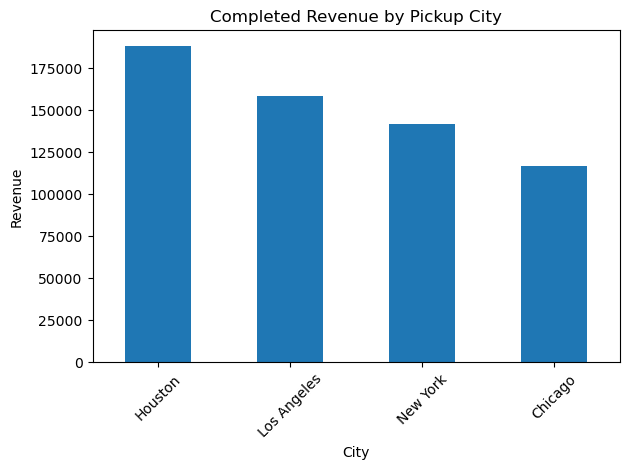

In [6]:
ax = revenue_by_city.plot(kind="bar", x="city", y="revenue", legend=False)
ax.set_title("Completed Revenue by Pickup City")
ax.set_xlabel("City")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Top pickup zones

In [7]:
q("""
SELECT
    l.city,
    l.zone_name,
    COUNT(*) AS pickup_count,
    ROUND(SUM(CASE WHEN t.status='completed' THEN t.total_fare ELSE 0 END), 2) AS revenue
FROM trips t
JOIN locations l
    ON t.pickup_location_id = l.location_id
GROUP BY l.city, l.zone_name
ORDER BY pickup_count DESC
LIMIT 10;
""")

,city,zone_name,pickup_count,revenue
0,New York,Flushing,607,17434.69
1,New York,Greenwich Village,593,12054.88
2,New York,Upper West Side,593,11927.03
3,New York,Times Square,582,10658.90
4,New York,JFK Airport,578,24373.69
5,Houston,Downtown Houston,568,16397.69
6,New York,LaGuardia Airport,566,21147.75
7,New York,Grand Central,563,9526.56
8,New York,Harlem,563,13431.68
9,Houston,Medical Center,556,13936.07


## Peak demand hours

In [8]:
peak_hours = q("""
SELECT
    CAST(strftime('%H', requested_at) AS INTEGER) AS hour,
    COUNT(*) AS requests,
    ROUND(AVG(surge_multiplier), 2) AS avg_surge,
    ROUND(100.0 * SUM(CASE WHEN status='cancelled' THEN 1 ELSE 0 END) / COUNT(*), 2) AS cancellation_rate_pct
FROM trips
GROUP BY hour
ORDER BY hour;
""")

peak_hours


,hour,requests,avg_surge,cancellation_rate_pct
0,0,840,1.38,15.12
1,1,866,1.36,16.40
2,2,866,1.02,14.78
3,3,819,1.02,14.77
4,4,798,1.02,15.16
5,5,818,1.02,13.94
6,6,780,1.01,12.56
7,7,810,1.89,13.58
8,8,870,1.92,15.29
9,9,843,1.02,12.22


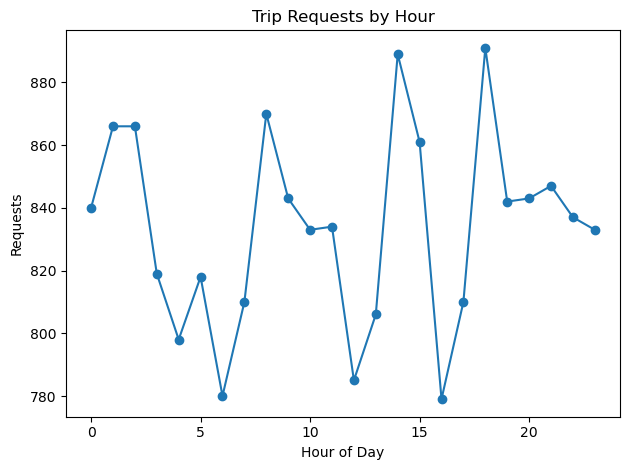

In [9]:
ax = peak_hours.plot(kind="line", x="hour", y="requests", marker="o", legend=False)
ax.set_title("Trip Requests by Hour")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Requests")
plt.tight_layout()
plt.show()


## Cancellation reasons

In [35]:
q("""
SELECT
    cancelled_by,
    reason,
    COUNT(*) AS cancellations
FROM cancellations
GROUP BY cancelled_by, reason
ORDER BY cancellations DESC
LIMIT 15;
""")

,cancelled_by,reason,cancellations
0,rider,too long wait,284
1,rider,changed my mind,283
2,rider,personal emergency,262
3,rider,waited too long,262
4,rider,price too high,250
5,rider,duplicate booking,249
6,rider,found another ride,248
7,rider,driver too far,231
8,driver,wrong pickup,137
9,driver,personal emergency,134


## Driver leaderboard

In [11]:
q("""
SELECT
    d.driver_id,
    u.name,
    u.city,
    d.vehicle_make,
    d.vehicle_model,
    COUNT(t.trip_id) AS completed_trips,
    ROUND(SUM(t.total_fare), 2) AS revenue,
    ROUND(AVG(t.total_fare), 2) AS avg_fare,
    d.rating
FROM trips t
JOIN drivers d
    ON t.driver_id = d.driver_id
JOIN users u
    ON d.user_id = u.user_id
WHERE t.status = 'completed'
GROUP BY d.driver_id, u.name, u.city, d.vehicle_make, d.vehicle_model, d.rating
ORDER BY revenue DESC
LIMIT 10;
""")

,driver_id,name,city,vehicle_make,vehicle_model,completed_trips,revenue,avg_fare,rating
0,10,Andrew Morales,Houston,Ford,Escape,76,3679.84,48.42,4.97
1,234,George Gray,Los Angeles,Toyota,Highlander,74,3484.90,47.09,4.71
2,57,Christopher Watson,Houston,Ford,F-150,73,3299.26,45.20,4.82
3,98,Jeffrey Ramirez,Los Angeles,Subaru,Outback,74,3279.39,44.32,4.96
4,303,Raymond Moore,Los Angeles,Tesla,Model X,64,3269.23,51.08,4.68
5,337,Justin Young,Houston,Tesla,Cybertruck,77,3111.72,40.41,4.87
6,34,Charles Cook,Los Angeles,Tesla,Model 3,62,3072.33,49.55,4.97
7,396,Jennifer Johnson,Los Angeles,Tesla,Cybertruck,69,3047.77,44.17,4.94
8,100,Debra Adams,Los Angeles,Chevrolet,Silverado,68,3041.11,44.72,4.40
9,63,Nancy Price,Los Angeles,Ford,Escape,60,3010.65,50.18,4.49


## Rider lifetime value

In [12]:
q("""
SELECT
    r.rider_id,
    u.name,
    u.city,
    COUNT(t.trip_id) AS completed_trips,
    ROUND(SUM(t.total_fare), 2) AS lifetime_value,
    ROUND(AVG(t.total_fare), 2) AS avg_trip_value,
    r.rating
FROM trips t
JOIN riders r
    ON t.rider_id = r.rider_id
JOIN users u
    ON r.user_id = u.user_id
WHERE t.status = 'completed'
GROUP BY r.rider_id, u.name, u.city, r.rating
ORDER BY lifetime_value DESC
LIMIT 10;
""")

,rider_id,name,city,completed_trips,lifetime_value,avg_trip_value,rating
0,739,Linda Gonzalez,New York,88,3485.26,39.61,3.42
1,689,Brian Collins,Chicago,87,3361.59,38.64,4.08
2,646,Emma Cooper,Houston,87,3288.69,37.80,3.44
3,1442,Elizabeth Walker,Los Angeles,87,3271.96,37.61,3.52
4,1288,Janet Hill,Los Angeles,94,3243.69,34.51,3.09
5,1559,Debra Howard,Houston,82,3196.50,38.98,3.81
6,1228,Edward Baker,Houston,75,3170.95,42.28,3.43
7,595,Alexander Davis,Houston,84,3158.86,37.61,3.52
8,833,Brian Green,Chicago,88,3156.54,35.87,4.97
9,301,Brenda Lee,Houston,78,3124.92,40.06,4.06


---

### End